# Основы искусственного интеллекта и машинного обучения

## Lec 01. Задания

### Исходные данные

Интерполяция

$X=\mathbb{R}$, $Y=\mathbb{R}$

Дано: $\left(x_1,f(x_1)\right), \left(x_2,f(x_2)\right),\ldots, \left(x_l,f(x_l)\right)$

Задача 1: Найти полином $P_l$, такой что $P_l(x_i)=f(x_i), i\in 1,\ldots,l$.

Задача 2: Выписать полином $P_l$ в явном виде.

Задача 3: Написать программу на Python, позволяющую по входным парам $(x_i , y_i)$
задать функцию, принимающую значения $y_i$ в точках $x_i$.

Задача 4: По данным из Housing.csv построить линейную модель предсказания цены.

### Решения задач

#### Задача 1 и 2

Полином $P_l$ уже нашли до меня, например Лагранж или Ньютон, рассмотрим полином Лагранжа:

##### Полином Лагранжа
Полином Лагранжа имеет вид:

$$
P_l(x) = \sum_{j=1}^l f(x_j) \, L_j(x),
$$

где базисные функции полинома Лагранжа определяются как

$$
L_j(x) = \prod_{\substack{m=1 \\ m \neq j}}^l \frac{x - x_m}{x_j - x_m}.
$$

Свойства:
- $L_j(x_j) = 1$,
- $L_j(x_m) = 0$ при $m \neq j$.

Благодаря этим свойствам выполняется условие интерполяции:

$$
P_l(x_i) = f(x_i), \quad i = 1, \dots, l.
$$

##### Полином Ньютона

Интерполяционный полином можно записать еще, например, в форме Ньютона.  
Для набора точек $((x_1, f(x_1)), (x_2, f(x_2)), \dots, (x_l, f(x_l))$ он имеет вид:

$$
P_l(x) = f[x_1] 
+ f[x_1, x_2](x - x_1) 
+ f[x_1, x_2, x_3](x - x_1)(x - x_2) 
+ \dots 
+ f[x_1, x_2, \dots, x_l](x - x_1)(x - x_2)\dots(x - x_{l-1}),
$$

где $f[x_i], f[x_i, x_{i+1}], \dots$ и так далее - это разделенные разности, которые достаточно трудоемко программировать, поэтому я этого не стал делать)) (ограничелся только полиномомо Лагранжа). Сами разделенные разности имеют вид:

1. первого порядка:
$$
f[x_i, x_{i+1}] = \frac{f(x_{i}+1) - f(x_i)}{x_{i+1} - x_i},
$$

2. второго порядка:
$$
f[x_i, x_{i+1}, x_{i+2}] = \frac{f[x_{i+1}, x_{i+2}] - f[x_i, x_{i+1}]}{x_{i+2} - x_i},
$$

3. ... и так далее рекурсивно


Как я уже отметил выше, реализовывать полином Ньютона программно я не стал, кроме этого по теореме о единственности существования интерполяционного полинома - они все равно будет совпадать.
Различие заключается лишь в форме представления: Лагранж - через базисные функции, Ньютон - через разделенные разности.

**Теорема.** Существует единственный полином степени не выше $l-1$, который удовлетворяет условиям интерполяции
$$
P(x_i) = f(x_i), \quad i = 1, \dots, l.
$$

Следовательно полином Лагранжа,полином Ньютона, а также любые другие формы записи интерполяционного полинома являются одним и тем же полиномом, лишь представленным в разных базисах

#### Задача 3

В качестве пар $\left(x_1,f(x_1)\right), \left(x_2,f(x_2)\right),\ldots, \left(x_l,f(x_l)\right)$ будем использовать функцию $\sin(x)$, $x\in\left[-\pi,\pi\right]$:

In [65]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

In [66]:
def lagrange_poly(x_vals: np.ndarray, y_vals: np.ndarray) -> np.poly1d:
    x_vals = np.asarray(x_vals, dtype = float)
    y_vals = np.asarray(y_vals, dtype = float)
    n = len(x_vals)
    if n != len(y_vals):
        print(f"[Error] : x_vals и y_vals должны быть одинаковой длины")
        return False
        
    P = np.poly1d([0.0])
    
    for j in range(n):
        numer = np.poly1d([1.0])
        denom = 1.0
        xj = x_vals[j]
        for m in range(n):
            if m == j:
                continue
            xm = x_vals[m]
            numer = np.polymul(numer, np.poly1d([1.0, -xm]))
            denom *= (xj - xm)
        Lj = numer * (1.0 / denom)
        P = P + Lj * y_vals[j]
        
    coeffs = np.round(P.coeffs, decimals=12)
    return coeffs

Подготовим пары для эксперимента:

In [67]:
h = 0.5
x = np.arange(-np.pi, np.pi + h, h)
y = np.sin(x)

table = np.column_stack((x, y))
print("   x  \t\t  sin(x)")
print(table)

   x  		  sin(x)
[[-3.14159265e+00 -1.22464680e-16]
 [-2.64159265e+00 -4.79425539e-01]
 [-2.14159265e+00 -8.41470985e-01]
 [-1.64159265e+00 -9.97494987e-01]
 [-1.14159265e+00 -9.09297427e-01]
 [-6.41592654e-01 -5.98472144e-01]
 [-1.41592654e-01 -1.41120008e-01]
 [ 3.58407346e-01  3.50783228e-01]
 [ 8.58407346e-01  7.56802495e-01]
 [ 1.35840735e+00  9.77530118e-01]
 [ 1.85840735e+00  9.58924275e-01]
 [ 2.35840735e+00  7.05540326e-01]
 [ 2.85840735e+00  2.79415498e-01]
 [ 3.35840735e+00 -2.15119988e-01]]


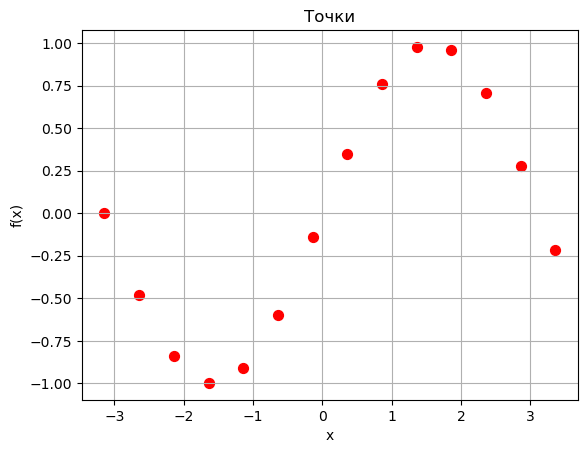

In [68]:
plt.scatter(x, y, color="red", s= 50)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Точки")
plt.grid(True)
plt.show()

In [69]:
coeffs = lagrange_poly(x, y)
print(coeffs)

[ 1.39000000e-10 -3.00000000e-12 -2.48180000e-08  7.10000000e-11
  2.75448000e-06 -5.20000000e-10 -1.98409319e-04  1.63400000e-09
  8.33332898e-03 -2.11800000e-09 -1.66666664e-01  9.01000000e-10
  1.00000000e+00 -5.50000000e-11]


In [70]:
# Можно посмотреть как будет выглядеть этот полином:
print((np.poly1d(coeffs)))

          13         12             11           10             9
1.39e-10 x  - 3e-12 x  - 2.482e-08 x  + 7.1e-11 x  + 2.754e-06 x
            8             7             6            5             4
 - 5.2e-10 x - 0.0001984 x + 1.634e-09 x + 0.008333 x - 2.118e-09 x
           3            2
 - 0.1667 x + 9.01e-10 x + 1 x - 5.5e-11


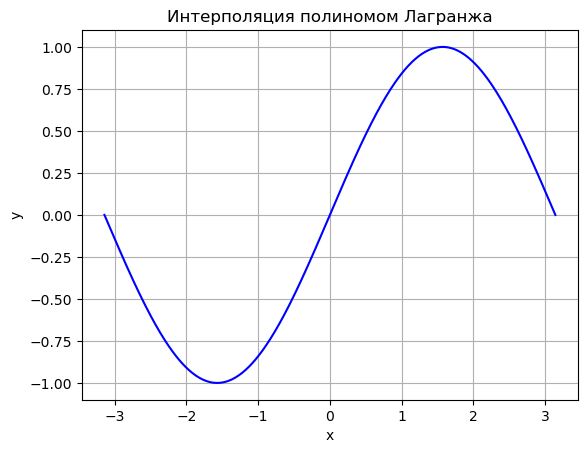

In [56]:
p = np.poly1d(coeffs)

xx = np.linspace(-np.pi, np.pi, 400)
yy = p(xx)

plt.plot(xx, yy, color="blue")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Интерполяция полиномом Лагранжа")
plt.grid(True)
plt.show()

Теперь решаем задачу интерполяции

In [57]:
arg = 3.53407346e-01
val = p(arg)
print(val)

0.34609657859353576


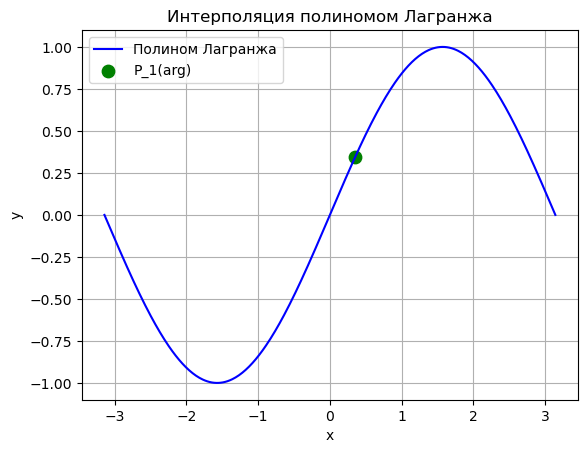

In [71]:
plt.plot(xx, yy, label="Полином Лагранжа", color="blue")
plt.scatter(arg, val, color="green", s=80, label=f"P_1(arg)")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Интерполяция полиномом Лагранжа")
plt.grid(True)
plt.legend()
plt.show()

Далее изобразим график $P_l(x)$ в сравнении с исходной функцией $f(x)=\sin(x)$

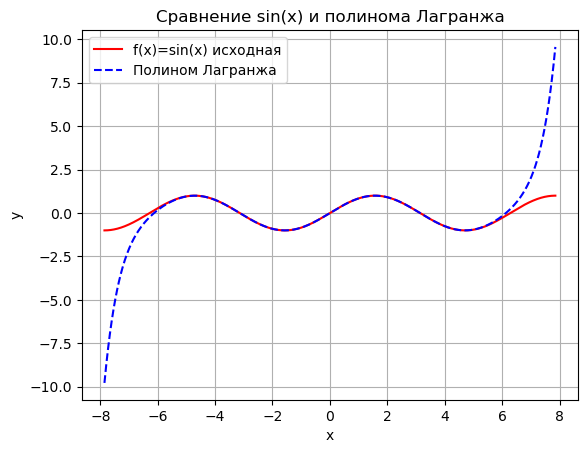

In [72]:
xx_new = np.linspace(-2.5*np.pi, 2.5*np.pi, 1000)
yy_sin = np.sin(xx_new)
yy_new = p(xx_new)

plt.plot(xx_new, yy_sin, label="f(x)=sin(x) исходная", color="red")
plt.plot(xx_new, yy_new, label="Полином Лагранжа", color="blue", linestyle="--")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Сравнение sin(x) и полинома Лагранжа")
plt.grid(True)
plt.legend(loc="upper left")
plt.show()

Видно, что можно интерполировать, даже немного экстраполировать используя данную "модель", но график говорит сам за себя.

#### Задача 4

In [73]:
def read_input_file(filepath: str) -> np.ndarray:
    try:
        data = np.genfromtxt(filepath, delimiter=",", dtype=None, encoding="utf-8", names=True)
        print(f"[Info] : Файл {filepath} успешно обнаружен.")
        return data
    except FileNotFoundError:
        print(f"[Error] : Файл {filepath} не обнаружен и считан.")
        return np.array([])

file_name = "Housing.csv"
data = read_input_file(file_name)
print("   №:   price: lotsize:")
print(data[:5]) # вывожу первые 5 строчек

[Info] : Файл Housing.csv успешно обнаружен.
   №:   price: lotsize:
[('"1"', 42000., 5850, 3, 1, 2, '"yes"', '"no"', '"yes"', '"no"', '"no"', 1, '"no"')
 ('"2"', 38500., 4000, 2, 1, 1, '"yes"', '"no"', '"no"', '"no"', '"no"', 0, '"no"')
 ('"3"', 49500., 3060, 3, 1, 1, '"yes"', '"no"', '"no"', '"no"', '"no"', 0, '"no"')
 ('"4"', 60500., 6650, 3, 1, 2, '"yes"', '"yes"', '"no"', '"no"', '"no"', 0, '"no"')
 ('"5"', 61000., 6360, 2, 1, 1, '"yes"', '"no"', '"no"', '"no"', '"no"', 0, '"no"')]


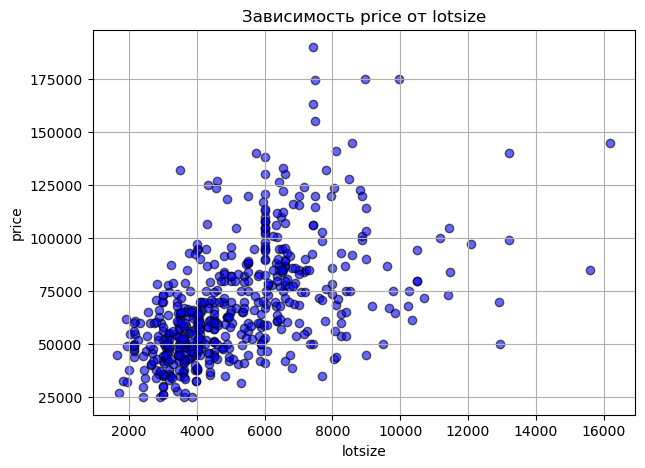

In [62]:
plt.figure(figsize=(7, 5))
plt.scatter(data["lotsize"], data["price"], c="blue", alpha=0.6, edgecolors="k", zorder = 1)

plt.xlabel("lotsize")
plt.ylabel("price")

plt.title("Зависимость price от lotsize")
plt.grid(True, zorder = -1)
plt.show()

In [63]:
X = data["lotsize"].reshape(-1, 1)
y = data["price"]

X_b = np.c_[np.ones((X.shape[0], 1)), X]  # shape: (m, 2)

theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

theta0, theta1 = theta
print(f"Линейная модель: price = {theta0:.2f} + {theta1:.2f} * lotsize")

Линейная модель: price = 34136.19 + 6.60 * lotsize


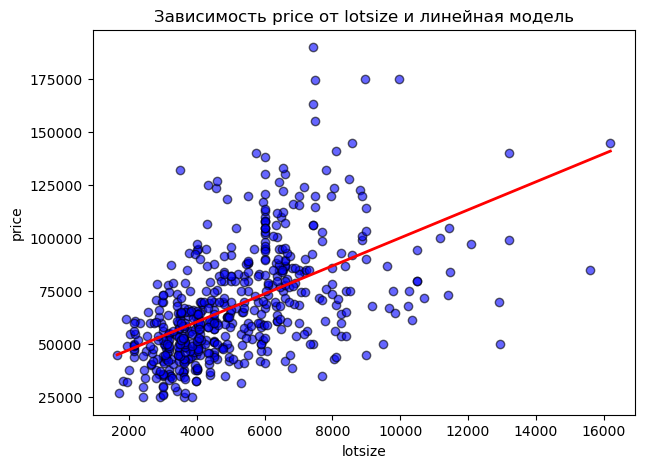

In [64]:
plt.figure(figsize=(7, 5))
plt.scatter(X, y, c="blue", alpha=0.6, edgecolors="k", zorder=3)

plt.xlabel("lotsize")
plt.ylabel("price")

plt.title("Зависимость price от lotsize и линейная модель")

x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
x_line_b = np.c_[np.ones((x_line.shape[0], 1)), x_line]
y_line = x_line_b @ theta

plt.plot(x_line, y_line, "r-", linewidth=2, zorder=4)